---
## Stage 1 — Imports, Configuration & Data Loading

In [2]:
# ============================================================
# 1.1 — IMPORTS
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score
)
from sklearn.inspection import permutation_importance
from imblearn.over_sampling import SMOTE

SEED = 42
np.random.seed(SEED)
print('✅ All libraries imported successfully.')

✅ All libraries imported successfully.


In [4]:
# ============================================================
# 1.2 — DATA LOADING FROM NASA FIRMS (7-day live MODIS feed)
# ============================================================
DATA_URL = 'https://firms.modaps.eosdis.nasa.gov/data/active_fire/modis-c6.1/csv/MODIS_C6_1_Global_7d.csv'

print(f'Loading data from:\n  {DATA_URL}\n')
df_raw = pd.read_csv(DATA_URL)

print(f'Shape          : {df_raw.shape}')
print(f'Columns        : {df_raw.columns.tolist()}')
print(f'\nFirst 5 rows:')
df_raw.head()

Loading data from:
  https://firms.modaps.eosdis.nasa.gov/data/active_fire/modis-c6.1/csv/MODIS_C6_1_Global_7d.csv

Shape          : (43279, 13)
Columns        : ['latitude', 'longitude', 'brightness', 'scan', 'track', 'acq_date', 'acq_time', 'satellite', 'confidence', 'version', 'bright_t31', 'frp', 'daynight']

First 5 rows:


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,confidence,version,bright_t31,frp,daynight
0,8.63451,-62.72946,304.66,1.72,1.29,2026-05-01,39,T,58,6.1NRT,290.06,9.24,N
1,8.63219,-62.74445,305.07,1.72,1.29,2026-05-01,39,T,58,6.1NRT,289.03,10.19,N
2,8.68387,-63.15867,300.36,1.85,1.33,2026-05-01,39,T,26,6.1NRT,276.83,9.41,N
3,9.04154,-62.24116,301.82,1.55,1.23,2026-05-01,39,T,44,6.1NRT,288.44,6.91,N
4,9.08790,-62.25409,303.56,1.55,1.23,2026-05-01,39,T,56,6.1NRT,289.06,8.51,N


In [5]:
# ============================================================
# 1.3 — TARGET VARIABLE ENGINEERING: risk_level
# ============================================================
# risk_score = normalised composite of brightness, frp, confidence
# risk_level = Low / Medium / High based on percentile thresholds

def compute_risk(row):
    """Simple normalised risk score (0–1 per column, then averaged)."""
    score = 0.0
    score += row.get('brightness', 300) / 500.0   # typical max ~500 K
    score += row.get('frp', 0)          / 1000.0  # typical max ~1000 MW
    score += row.get('confidence', 50)  / 100.0
    return score / 3.0                             # average of 3 signals

df_raw['risk_score'] = df_raw.apply(compute_risk, axis=1)

# Percentile-based thresholds
p33 = df_raw['risk_score'].quantile(0.33)
p66 = df_raw['risk_score'].quantile(0.66)

def label_risk(score):
    if score <= p33:
        return 'Low'
    elif score <= p66:
        return 'Medium'
    else:
        return 'High'

df_raw['risk_level'] = df_raw['risk_score'].apply(label_risk)

print('Risk level distribution:')
print(df_raw['risk_level'].value_counts())
print(f'\nThresholds → Low ≤ {p33:.4f} | Medium ≤ {p66:.4f} | High > {p66:.4f}')

Risk level distribution:
risk_level
High      14715
Low       14284
Medium    14280
Name: count, dtype: int64

Thresholds → Low ≤ 0.4078 | Medium ≤ 0.4647 | High > 0.4647


---
## Stage 2 — Data Collection & Data Understanding

In [6]:
# Missing value analysis
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('--- Missing Value Report ---')
print(missing_df[missing_df['Missing Count'] > 0])

print('\n--- Sample Column Values ---')
for col in df_raw.columns:
    print(f'  {col}: {df_raw[col].unique()[:5]}')

--- Missing Value Report ---
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

--- Sample Column Values ---
  latitude: [8.63451 8.63219 8.68387 9.04154 9.0879 ]
  longitude: [-62.72946 -62.74445 -63.15867 -62.24116 -62.25409]
  brightness: [304.66 305.07 300.36 301.82 303.56]
  scan: [1.72 1.85 1.55 1.37 2.5 ]
  track: [1.29 1.33 1.23 1.16 1.52]
  acq_date: ['2026-05-01' '2026-05-02' '2026-05-03' '2026-05-04' '2026-05-05']
  acq_time: [39 35 41 30 33]
  satellite: ['T' 'A']
  confidence: [58 26 44 56 73]
  version: ['6.1NRT']
  bright_t31: [290.06 289.03 276.83 288.44 289.06]
  frp: [ 9.24 10.19  9.41  6.91  8.51]
  daynight: ['N' 'D']
  risk_score: [0.39952    0.40011    0.29004333 0.35018333 0.39187667]
  risk_level: ['Low' 'Medium' 'High']


In [7]:
# Geographic coverage
print(f"Latitude range   : {df_raw['latitude'].min():.2f} → {df_raw['latitude'].max():.2f}")
print(f"Longitude range  : {df_raw['longitude'].min():.2f} → {df_raw['longitude'].max():.2f}")
print(f"Acquisition dates: {df_raw['acq_date'].unique()}")
print(f"Satellites       : {df_raw['satellite'].unique()}")
print(f"Day/Night split  :\n{df_raw['daynight'].value_counts()}")

Latitude range   : -45.67 → 67.56
Longitude range  : -176.48 → 176.69
Acquisition dates: ['2026-05-01' '2026-05-02' '2026-05-03' '2026-05-04' '2026-05-05'
 '2026-05-06' '2026-05-07' '2026-05-08']
Satellites       : ['T' 'A']
Day/Night split  :
daynight
D    35705
N     7574
Name: count, dtype: int64


---
## Stage 3 — Data Preprocessing & Cleaning

In [8]:
# ============================================================
# 3.1 — MAKE A WORKING COPY
# ============================================================
df = df_raw.copy()

# ============================================================
# 3.2 — DROP IRRELEVANT / IDENTIFIER COLUMNS
# ============================================================
drop_cols = ['version']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
print('Dropped metadata columns:', drop_cols)

# ============================================================
# 3.3 — DATETIME PARSING & FEATURE EXTRACTION
# ============================================================
df['acq_date'] = pd.to_datetime(df['acq_date'])
df['day_of_year'] = df['acq_date'].dt.dayofyear
df['month']       = df['acq_date'].dt.month
df['day_of_week'] = df['acq_date'].dt.dayofweek

# acq_time → hour (0–23)
df['hour'] = df['acq_time'].astype(str).str.zfill(4).str[:2].astype(int)

print('Datetime features extracted: day_of_year, month, day_of_week, hour')
df.drop(columns=['acq_date', 'acq_time'], inplace=True)

Dropped metadata columns: ['version']
Datetime features extracted: day_of_year, month, day_of_week, hour


In [9]:
# ============================================================
# 3.4 — ENCODE CATEGORICAL COLUMNS
# ============================================================

# daynight: D=1, N=0
df['daynight'] = df['daynight'].map({'D': 1, 'N': 0})
print('daynight encoded → D=1, N=0')

# satellite: label encode
le_sat = LabelEncoder()
df['satellite'] = le_sat.fit_transform(df['satellite'].astype(str))
print('satellite label encoded:', dict(zip(le_sat.classes_, le_sat.transform(le_sat.classes_))))

daynight encoded → D=1, N=0
satellite label encoded: {'A': np.int64(0), 'T': np.int64(1)}


In [10]:
# ============================================================
# 3.5 — HANDLE MISSING VALUES
# ============================================================
print('Missing before imputation:')
print(df.isnull().sum()[df.isnull().sum() > 0])

num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print('\nMissing after imputation:')
print(df.isnull().sum().sum(), 'total missing values')

Missing before imputation:
Series([], dtype: int64)

Missing after imputation:
0 total missing values


In [11]:
# ============================================================
# 3.6 — OUTLIER DETECTION & HANDLING (IQR method)
# ============================================================
def iqr_clip(series, factor=3.0):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return series.clip(Q1 - factor * IQR, Q3 + factor * IQR)

for col in ['frp', 'brightness', 'bright_t31', 'scan', 'track']:
    if col in df.columns:
        before_max = df[col].max()
        df[col] = iqr_clip(df[col])
        print(f'  {col}: max before={before_max:.2f} → after={df[col].max():.2f}')

print('\n✅ Outliers clipped using 3×IQR rule')

  frp: max before=2769.14 → after=79.41
  brightness: max before=492.85 → after=370.80
  bright_t31: max before=400.07 → after=327.98
  scan: max before=4.82 → after=3.20
  track: max before=2.00 → after=1.90

✅ Outliers clipped using 3×IQR rule


In [12]:
# Final cleaned dataset overview
print('--- Cleaned Dataset Sample ---')
df.head()

--- Cleaned Dataset Sample ---


,latitude,longitude,brightness,scan,track,satellite,confidence,bright_t31,frp,daynight,risk_score,risk_level,day_of_year,month,day_of_week,hour
0,8.63451,-62.72946,304.66,1.72,1.29,1,58,290.06,9.24,0,0.399520,Low,121,5,4,0
1,8.63219,-62.74445,305.07,1.72,1.29,1,58,289.03,10.19,0,0.400110,Low,121,5,4,0
2,8.68387,-63.15867,300.36,1.85,1.33,1,26,276.83,9.41,0,0.290043,Low,121,5,4,0
3,9.04154,-62.24116,301.82,1.55,1.23,1,44,288.44,6.91,0,0.350183,Low,121,5,4,0
4,9.08790,-62.25409,303.56,1.55,1.23,1,56,289.06,8.51,0,0.391877,Low,121,5,4,0


---
## Stage 4 — Exploratory Data Analysis (EDA)

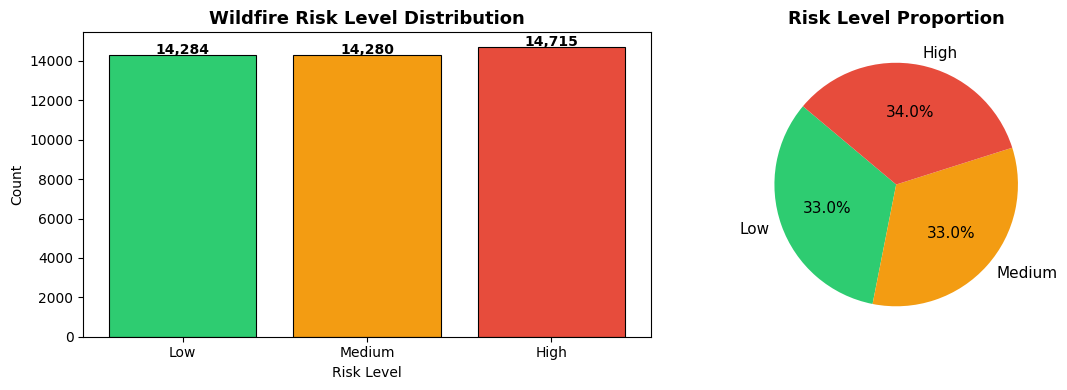

📊 Class distribution plot saved.


In [13]:
# ============================================================
# 4.1 — TARGET CLASS DISTRIBUTION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {'Low': '#2ECC71', 'Medium': '#F39C12', 'High': '#E74C3C'}
risk_counts = df['risk_level'].value_counts().reindex(['Low', 'Medium', 'High'])

bars = axes[0].bar(risk_counts.index, risk_counts.values,
                   color=[colors[c] for c in risk_counts.index], edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, risk_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Wildfire Risk Level Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Risk Level')

axes[1].pie(risk_counts.values, labels=risk_counts.index,
            colors=[colors[c] for c in risk_counts.index],
            autopct='%1.1f%%', startangle=140, textprops={'fontsize': 11})
axes[1].set_title('Risk Level Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Class distribution plot saved.')

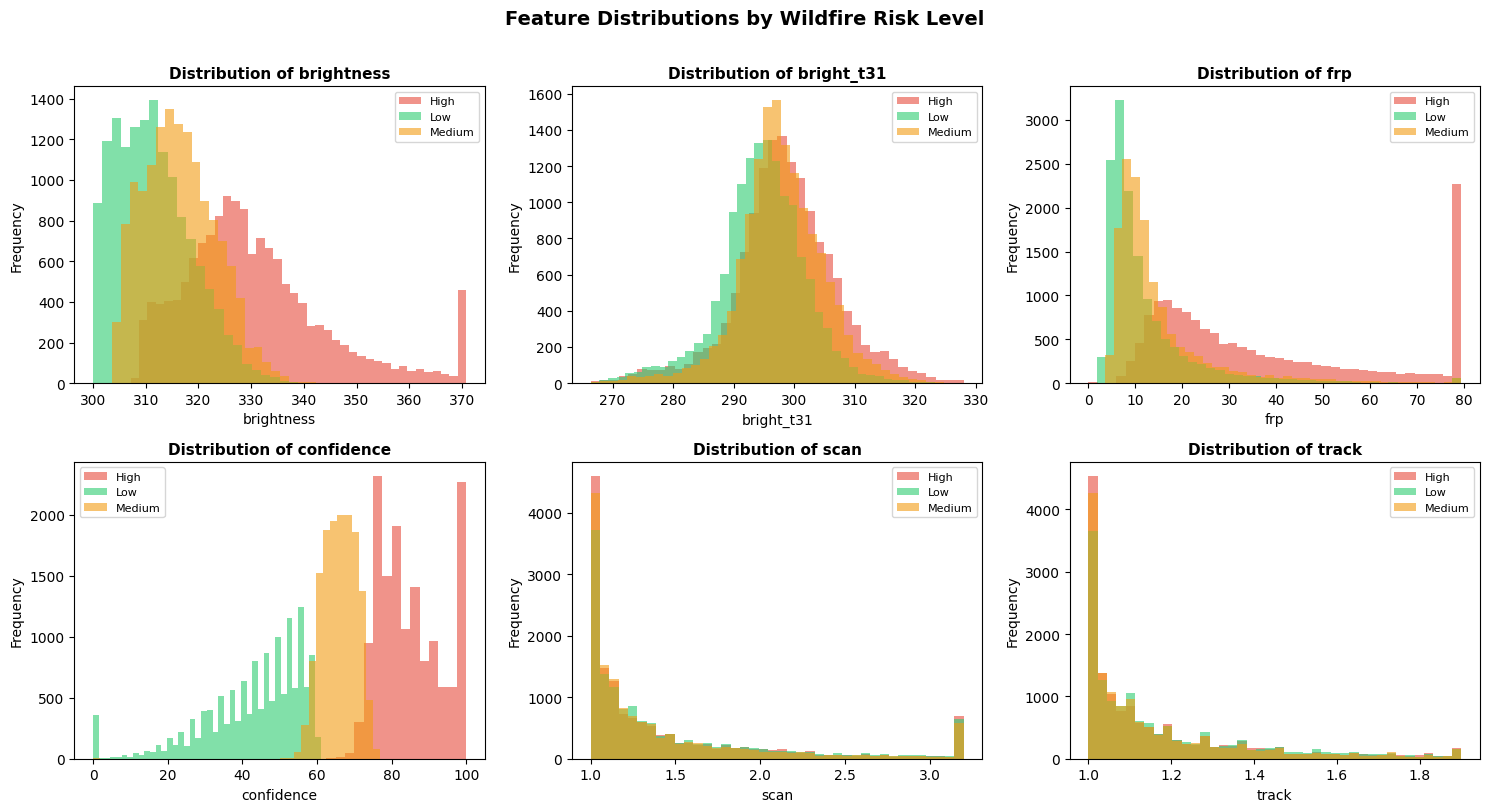

In [14]:
# ============================================================
# 4.2 — FEATURE DISTRIBUTIONS BY RISK LEVEL
# ============================================================
features_to_plot = ['brightness', 'bright_t31', 'frp', 'confidence', 'scan', 'track']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

palette = {'Low': '#2ECC71', 'Medium': '#F39C12', 'High': '#E74C3C'}

for i, feat in enumerate(features_to_plot):
    if feat in df.columns:
        for risk, grp in df.groupby('risk_level'):
            axes[i].hist(grp[feat], bins=40, alpha=0.6,
                         label=risk, color=palette.get(risk, 'gray'), edgecolor='none')
        axes[i].set_title(f'Distribution of {feat}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel(feat)
        axes[i].set_ylabel('Frequency')
        axes[i].legend(fontsize=8)

plt.suptitle('Feature Distributions by Wildfire Risk Level', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

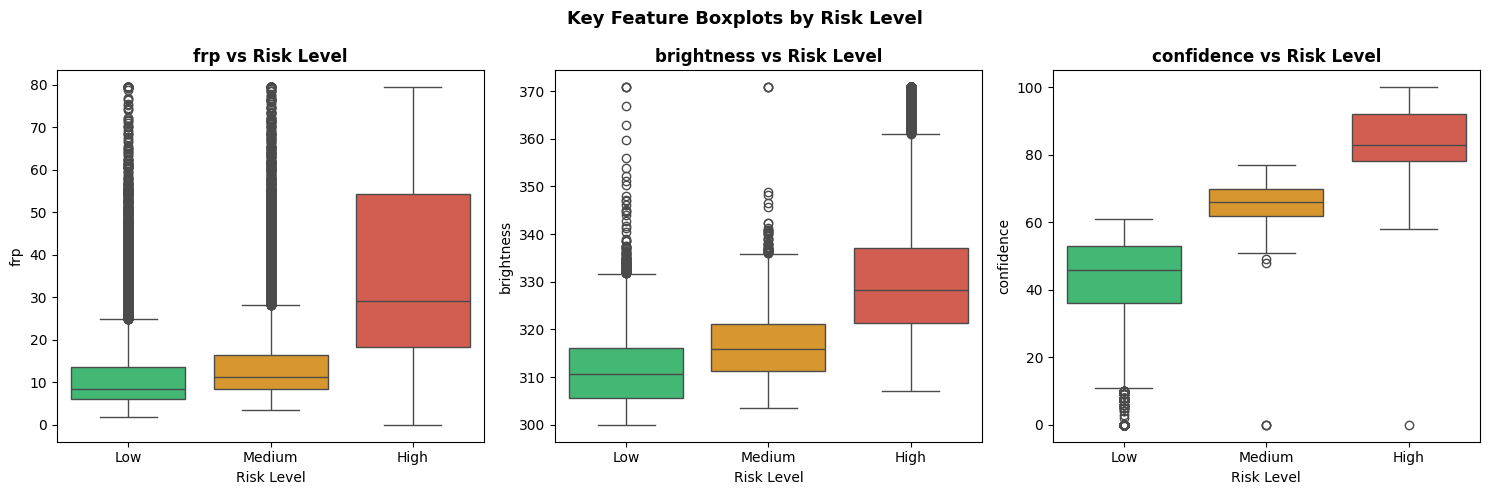

In [15]:
# ============================================================
# 4.3 — BOXPLOTS: KEY FEATURES vs RISK LEVEL
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

order = ['Low', 'Medium', 'High']
for ax, feat in zip(axes, ['frp', 'brightness', 'confidence']):
    sns.boxplot(data=df, x='risk_level', y=feat, order=order, palette=palette, ax=ax)
    ax.set_title(f'{feat} vs Risk Level', fontsize=12, fontweight='bold')
    ax.set_xlabel('Risk Level')

plt.suptitle('Key Feature Boxplots by Risk Level', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

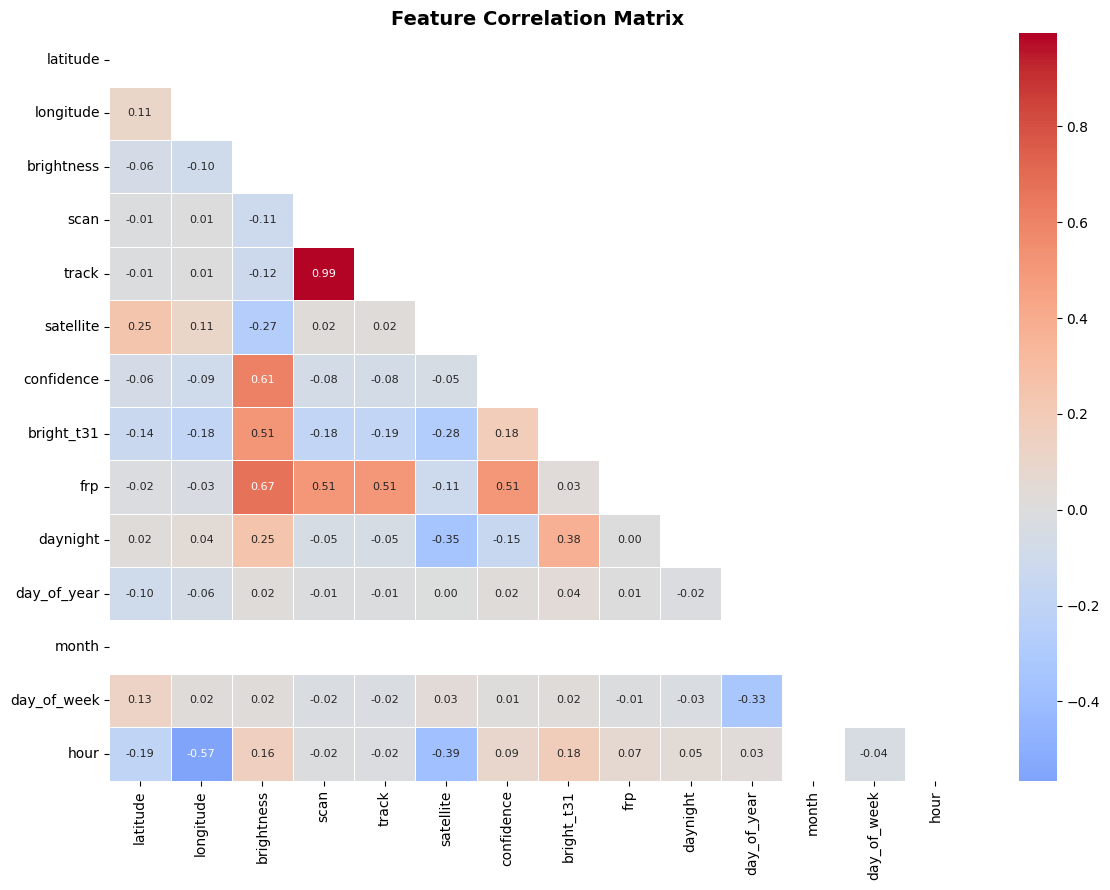

In [16]:
# ============================================================
# 4.4 — CORRELATION HEATMAP
# ============================================================
num_df = df.select_dtypes(include=[np.number]).drop(columns=['risk_score'], errors='ignore')
corr = num_df.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

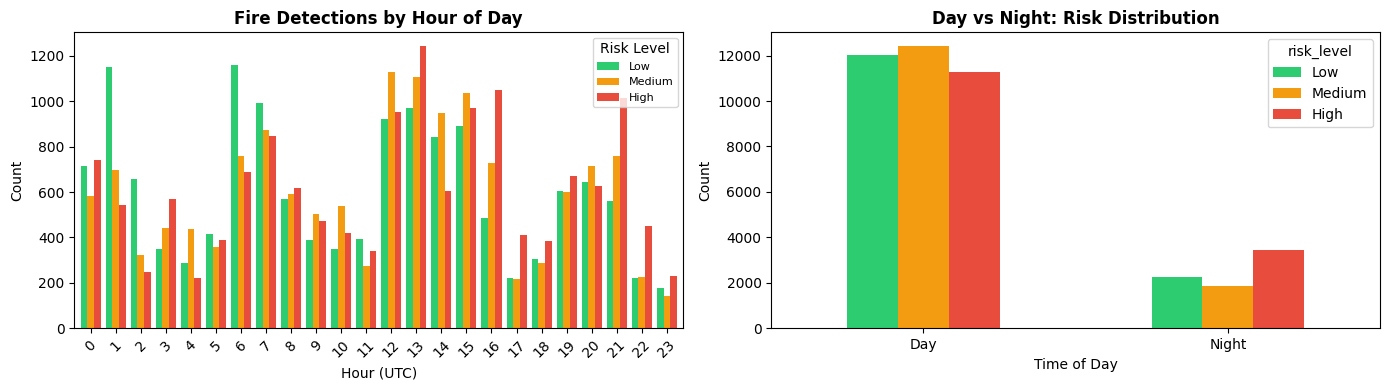

In [17]:
# ============================================================
# 4.5 — TEMPORAL EDA: FIRES BY HOUR AND DAY
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hour_counts = df.groupby(['hour', 'risk_level']).size().unstack(fill_value=0)
hour_counts = hour_counts.reindex(columns=['Low', 'Medium', 'High'], fill_value=0)
hour_counts.plot(kind='bar', ax=axes[0], color=['#2ECC71', '#F39C12', '#E74C3C'],
                 edgecolor='none', width=0.8)
axes[0].set_title('Fire Detections by Hour of Day', fontweight='bold')
axes[0].set_xlabel('Hour (UTC)')
axes[0].set_ylabel('Count')
axes[0].legend(title='Risk Level', fontsize=8)
axes[0].tick_params(axis='x', rotation=45)

dn_map = {0: 'Night', 1: 'Day'}
df['dn_label'] = df['daynight'].map(dn_map)
dn_risk = df.groupby(['dn_label', 'risk_level']).size().unstack(fill_value=0)
dn_risk = dn_risk.reindex(columns=['Low', 'Medium', 'High'], fill_value=0)
dn_risk.plot(kind='bar', ax=axes[1], color=['#2ECC71', '#F39C12', '#E74C3C'], edgecolor='none')
axes[1].set_title('Day vs Night: Risk Distribution', fontweight='bold')
axes[1].set_xlabel('Time of Day')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)
df.drop(columns=['dn_label'], inplace=True)

plt.tight_layout()
plt.savefig('eda_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ============================================================
# 4.6 — GEOGRAPHIC SCATTER: SPATIAL FIRE DISTRIBUTION
# ============================================================
sample = df.sample(min(10000, len(df)), random_state=SEED)

fig = px.scatter_geo(
    sample,
    lat='latitude', lon='longitude',
    color='risk_level',
    color_discrete_map={'Low': '#2ECC71', 'Medium': '#F39C12', 'High': '#E74C3C'},
    size='frp', size_max=8,
    hover_data=['confidence', 'brightness', 'frp'],
    title='🌍 Global Wildfire Risk Map (7-Day MODIS)',
    projection='natural earth',
    opacity=0.65
)
fig.update_layout(height=500, legend_title='Risk Level')
fig.show()
print('🗺️ Interactive Risk Map rendered.')

🗺️ Interactive Risk Map rendered.


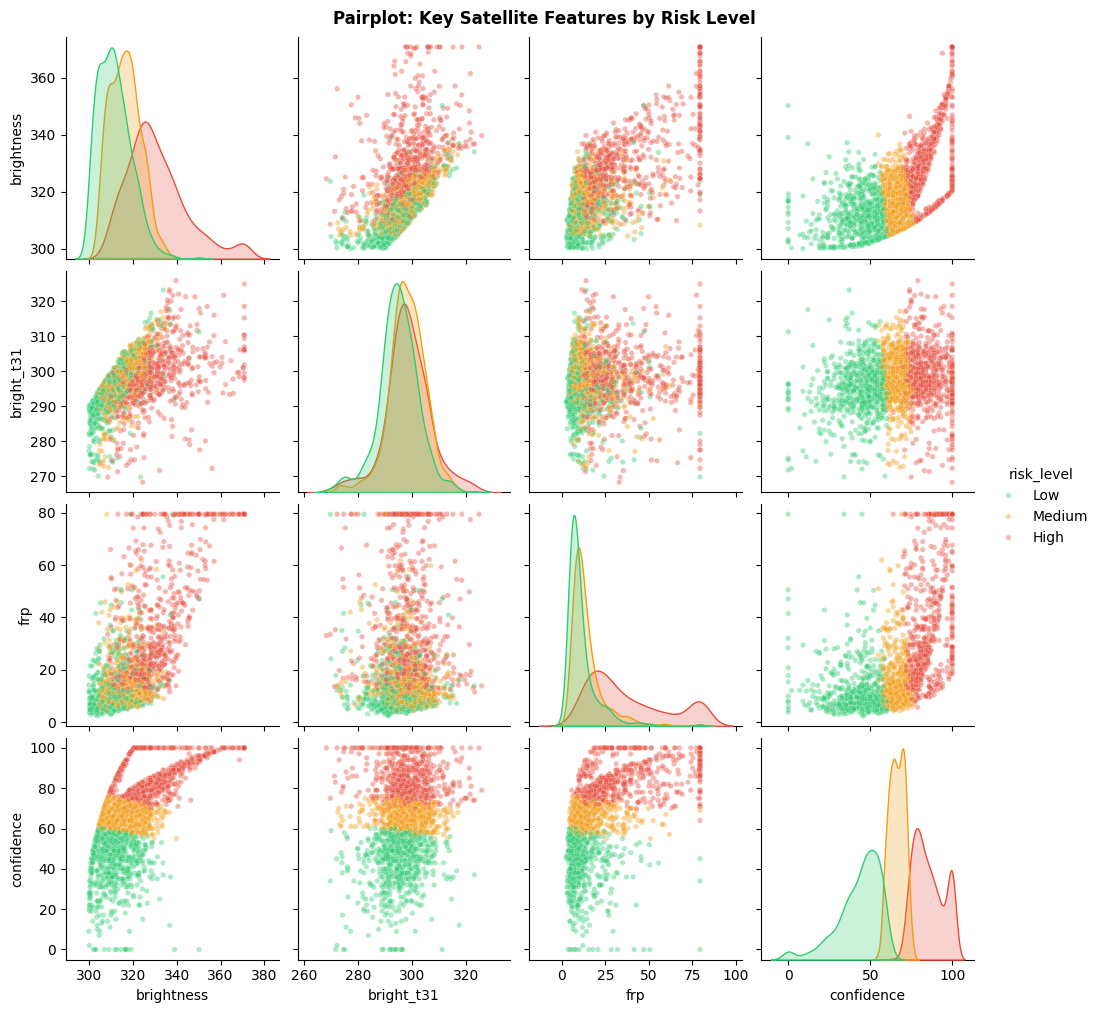

In [19]:
# ============================================================
# 4.7 — PAIRPLOT (subset of key features)
# ============================================================
pair_cols = ['brightness', 'bright_t31', 'frp', 'confidence', 'risk_level']
pair_df = df[pair_cols].sample(min(2000, len(df)), random_state=SEED)

g = sns.pairplot(pair_df, hue='risk_level', palette=palette,
                 plot_kws={'alpha': 0.4, 's': 15}, diag_kind='kde')
g.fig.suptitle('Pairplot: Key Satellite Features by Risk Level', y=1.01, fontweight='bold')
plt.savefig('eda_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Stage 5 — Feature Engineering & Selection

In [20]:
# ============================================================
# 5.1 — ENGINEER NEW FEATURES
# ============================================================

df['brightness_diff']   = df['brightness'] - df['bright_t31']
df['pixel_area']        = df['scan'] * df['track']
df['frp_per_area']      = df['frp'] / (df['pixel_area'] + 1e-9)
df['conf_weighted_frp'] = df['frp'] * (df['confidence'] / 100.0)
df['is_high_conf']      = (df['confidence'] >= 80).astype(int)

def get_season(month):
    if month in [12, 1, 2]:  return 0   # Winter
    elif month in [3, 4, 5]: return 1   # Spring
    elif month in [6, 7, 8]: return 2   # Summer
    else:                    return 3   # Autumn

df['season'] = df['month'].apply(get_season)

print('✅ Engineered features added:')
new_feats = ['brightness_diff', 'pixel_area', 'frp_per_area', 'conf_weighted_frp', 'is_high_conf', 'season']
for f in new_feats:
    print(f'  • {f}: mean={df[f].mean():.4f}, std={df[f].std():.4f}')

✅ Engineered features added:
  • brightness_diff: mean=22.6159, std=11.1216
  • pixel_area: mean=1.8062, std=1.2053
  • frp_per_area: mean=13.0007, std=12.1541
  • conf_weighted_frp: mean=16.0848, std=18.6172
  • is_high_conf: mean=0.2214, std=0.4152
  • season: mean=1.0000, std=0.0000


In [21]:
# ============================================================
# 5.2 — DEFINE FEATURE MATRIX X AND TARGET y
# ============================================================
# Columns to exclude from feature matrix
EXCLUDE = ['risk_level', 'risk_score']

# Keep only numeric columns that are not target/identifier
FEATURES = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in EXCLUDE
]

X = df[FEATURES].copy()

# Encode target
le_target = LabelEncoder()
y_enc = le_target.fit_transform(df['risk_level'])
class_names = le_target.classes_

print(f'Feature matrix shape : {X.shape}')
print(f'Features used        : {FEATURES}')
print(f'Class mapping        : {dict(zip(class_names, le_target.transform(class_names)))}')

Feature matrix shape : (43279, 20)
Features used        : ['latitude', 'longitude', 'brightness', 'scan', 'track', 'satellite', 'confidence', 'bright_t31', 'frp', 'daynight', 'day_of_year', 'month', 'day_of_week', 'hour', 'brightness_diff', 'pixel_area', 'frp_per_area', 'conf_weighted_frp', 'is_high_conf', 'season']
Class mapping        : {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


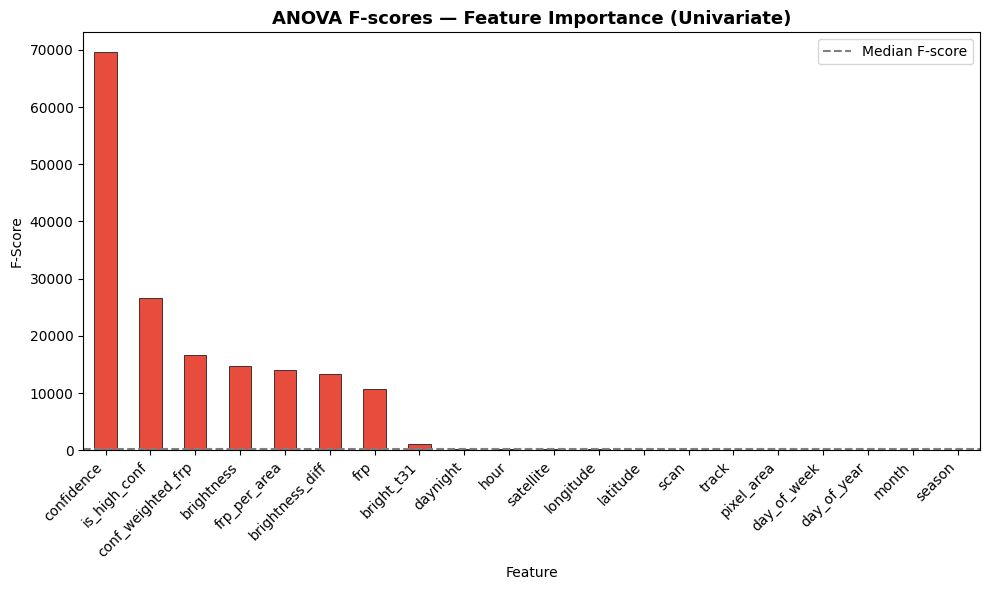


Top 10 Features by ANOVA F-score:
confidence           69571.824237
is_high_conf         26651.023930
conf_weighted_frp    16597.665418
brightness           14762.499849
frp_per_area         14054.581046
brightness_diff      13390.604657
frp                  10748.694466
bright_t31            1077.274249
daynight               290.260592
hour                   233.998829


In [22]:
# ============================================================
# 5.3 — FEATURE SELECTION: Univariate (ANOVA F-test)
# ============================================================
selector = SelectKBest(f_classif, k='all')
selector.fit(X, y_enc)

f_scores = pd.Series(selector.scores_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors_bar = ['#E74C3C' if s > f_scores.median() else '#3498DB' for s in f_scores]
f_scores.plot(kind='bar', color=colors_bar, edgecolor='black', linewidth=0.5)
plt.axhline(f_scores.median(), linestyle='--', color='gray', label='Median F-score')
plt.title('ANOVA F-scores — Feature Importance (Univariate)', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('F-Score')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('feature_selection_anova.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 Features by ANOVA F-score:')
print(f_scores.head(10).to_string())

In [23]:
# ============================================================
# 5.4 — SELECT TOP FEATURES (above median F-score)
# ============================================================
top_features = f_scores[f_scores > f_scores.median()].index.tolist()
print(f'Selected {len(top_features)} features: {top_features}')

X_selected = X[top_features]

Selected 9 features: ['confidence', 'is_high_conf', 'conf_weighted_frp', 'brightness', 'frp_per_area', 'brightness_diff', 'frp', 'bright_t31', 'daynight']


In [24]:
# ============================================================
# 5.5 — TRAIN / TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_enc,
    test_size=0.2, random_state=SEED, stratify=y_enc
)
print(f'Train size : {X_train.shape[0]:,} rows')
print(f'Test size  : {X_test.shape[0]:,} rows')

Train size : 34,623 rows
Test size  : 8,656 rows


In [25]:
# ============================================================
# 5.6 — CLASS BALANCING WITH SMOTE
# ============================================================
smote = SMOTE(random_state=SEED)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('Class distribution after SMOTE:')
unique, counts = np.unique(y_train_bal, return_counts=True)
for cls, cnt in zip(le_target.inverse_transform(unique), counts):
    print(f'  {cls}: {cnt:,}')

Class distribution after SMOTE:
  High: 11,772
  Low: 11,772
  Medium: 11,772


In [26]:
# ============================================================
# 5.7 — FEATURE SCALING (required for SVM)
# ============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

print('✅ StandardScaler applied. Fitted on training set only.')

✅ StandardScaler applied. Fitted on training set only.


---
## Stage 6 — Model Building & Training (SVM Only)

In [27]:
# ============================================================
# 6.1 — SUPPORT VECTOR MACHINE (SVM) with GridSearchCV
# ============================================================
print('Training SVM (RBF kernel) with GridSearchCV...')
print('Note: SVM uses SCALED features.\n')

svm_params = {
    'C'     : [0.1, 1, 10],
    'gamma' : ['scale', 'auto'],
    'kernel': ['rbf']
}

svm_base = SVC(probability=True, random_state=SEED, class_weight='balanced')
svm_cv = GridSearchCV(
    svm_base, svm_params,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring='f1_macro', n_jobs=-1, verbose=1
)
svm_cv.fit(X_train_scaled, y_train_bal)

svm_best = svm_cv.best_estimator_
print(f'\n✅ Best SVM params  : {svm_cv.best_params_}')
print(f'   Best CV F1-macro : {svm_cv.best_score_:.4f}')

Training SVM (RBF kernel) with GridSearchCV...
Note: SVM uses SCALED features.

Fitting 3 folds for each of 6 candidates, totalling 18 fits

✅ Best SVM params  : {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
   Best CV F1-macro : 0.9946


---
## Stage 7 — Model Evaluation

In [28]:
# ============================================================
# 7.1 — PREDICTIONS & METRICS
# ============================================================
y_pred_svm  = svm_best.predict(X_test_scaled)
y_prob_svm  = svm_best.predict_proba(X_test_scaled)

acc_svm  = accuracy_score(y_test, y_pred_svm)
f1m_svm  = f1_score(y_test, y_pred_svm, average='macro')
f1w_svm  = f1_score(y_test, y_pred_svm, average='weighted')
roc_svm  = roc_auc_score(y_test, y_prob_svm, multi_class='ovr', average='macro')

results = pd.DataFrame([{
    'Model'        : 'SVM (RBF)',
    'Accuracy'     : round(acc_svm, 4),
    'F1-Macro'     : round(f1m_svm, 4),
    'F1-Weighted'  : round(f1w_svm, 4),
    'ROC-AUC (OvR)': round(roc_svm, 4)
}])

print('\n=== SVM Performance Summary ===')
print(results.to_string(index=False))


=== SVM Performance Summary ===
    Model  Accuracy  F1-Macro  F1-Weighted  ROC-AUC (OvR)
SVM (RBF)     0.995     0.995        0.995            1.0


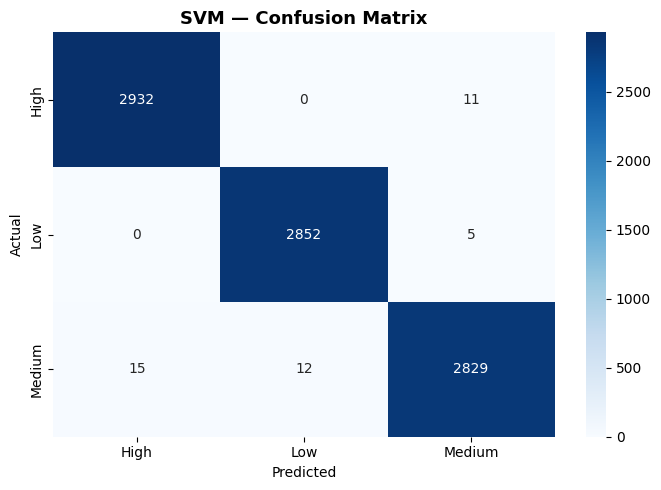

In [29]:
# ============================================================
# 7.2 — CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_test, y_pred_svm, labels=le_target.transform(class_names))

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('SVM — Confusion Matrix', fontsize=13, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('svm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

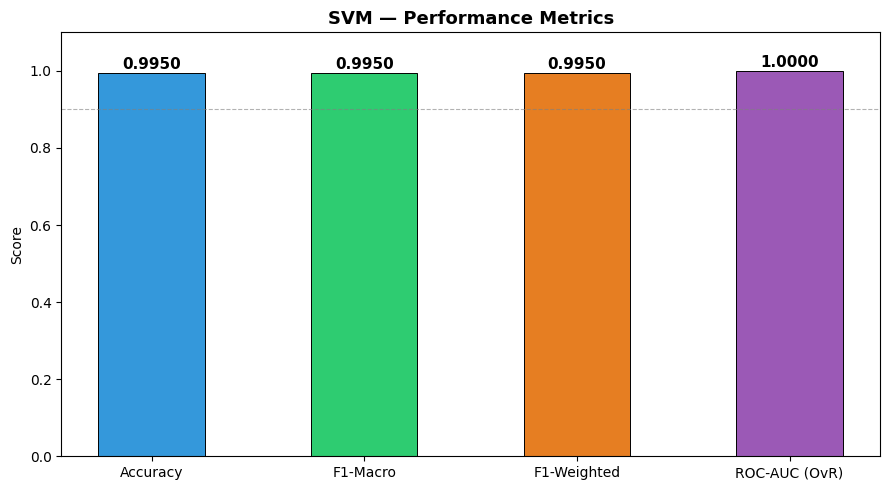

In [30]:
# ============================================================
# 7.3 — METRIC BAR CHART
# ============================================================
metrics_to_plot = ['Accuracy', 'F1-Macro', 'F1-Weighted', 'ROC-AUC (OvR)']
metric_values   = [results[m].values[0] for m in metrics_to_plot]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(metrics_to_plot, metric_values, color=['#3498DB', '#2ECC71', '#E67E22', '#9B59B6'],
              edgecolor='black', linewidth=0.7, width=0.5)
for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('SVM — Performance Metrics', fontsize=13, fontweight='bold')
ax.axhline(0.9, linestyle='--', color='gray', linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.savefig('svm_metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# ============================================================
# 7.4 — CLASSIFICATION REPORT
# ============================================================
print('='*55)
print(' Classification Report — SVM (RBF)')
print('='*55)
print(classification_report(y_test, y_pred_svm, target_names=class_names))

 Classification Report — SVM (RBF)
              precision    recall  f1-score   support

        High       0.99      1.00      1.00      2943
         Low       1.00      1.00      1.00      2857
      Medium       0.99      0.99      0.99      2856

    accuracy                           1.00      8656
   macro avg       1.00      1.00      1.00      8656
weighted avg       1.00      1.00      1.00      8656



---
## Stage 8 — Model Interpretation & Explainability

Computing SVM permutation importance (this may take ~1 min)...


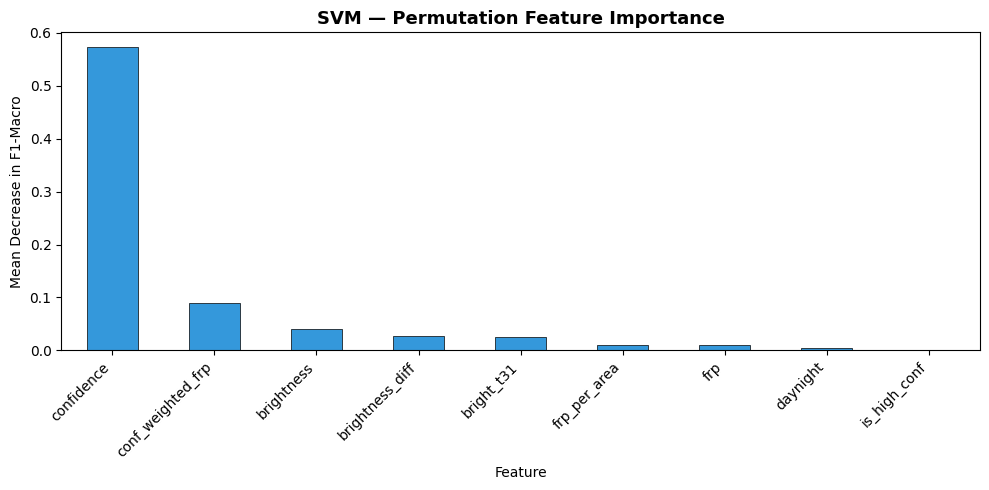


Top 5 Features (Permutation Importance):
confidence           0.572322
conf_weighted_frp    0.089591
brightness           0.041008
brightness_diff      0.027638
bright_t31           0.024458
dtype: float64


In [32]:
# ============================================================
# 8.1 — SVM: PERMUTATION IMPORTANCE
# ============================================================
print('Computing SVM permutation importance (this may take ~1 min)...')
perm_imp = permutation_importance(
    svm_best, X_test_scaled, y_test,
    n_repeats=10, random_state=SEED, scoring='f1_macro', n_jobs=-1
)
perm_df = pd.Series(perm_imp.importances_mean, index=top_features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
perm_df.plot(kind='bar', color='#3498DB', edgecolor='black', linewidth=0.5)
plt.title('SVM — Permutation Feature Importance', fontsize=13, fontweight='bold')
plt.ylabel('Mean Decrease in F1-Macro')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('svm_permutation_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 5 Features (Permutation Importance):')
print(perm_df.head())

---
## Stage 9 — Deployment (Streamlit App)

Save the trained model and scaler for deployment.

In [33]:
import joblib

joblib.dump(svm_best, 'wildfire_svm_model.pkl')
joblib.dump(scaler,   'wildfire_scaler.pkl')
joblib.dump(le_target,'wildfire_label_encoder.pkl')

print('✅ Model artefacts saved:')
print('   wildfire_svm_model.pkl')
print('   wildfire_scaler.pkl')
print('   wildfire_label_encoder.pkl')

✅ Model artefacts saved:
   wildfire_svm_model.pkl
   wildfire_scaler.pkl
   wildfire_label_encoder.pkl
